# Looped Geometry of Interaction

[`neural-functors.ipynb`](neural-functors.ipynb) builds the wiring formalism of `discopy.neural` from its categorical definition up. This notebook is the complementary close-up, focused on a single model: Deep GoI, the segmented-recursion solver of `docs/neural` that reaches above 99% board-solve accuracy on the nine-by-nine sudoku benchmark of Palm et al. (2018). We state the syntactic category it interprets, open the cell and the unit it becomes, verify their equations against the code, train the recursion for real under a small budget, and point to the documented recipe that reaches the full number.

This notebook is GPU-only, since it trains on the benchmark and measures activation memory on the device.

In [3]:
import sys
import time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "this notebook is GPU-only"
device = torch.device("cuda")
torch.set_float32_matmul_precision("high")     # TF32 matmuls on Ampere+

# the study code lives in docs/neural, a sibling of this notebook's folder
sys.path.insert(0, str(Path.cwd().parent / "neural"))
from sudoku import data as datasets
from sudoku import models as zoo
from sudoku import skeleton
from sudoku import sudoku_extreme
from sudoku.config import Widths, ARTIFACTS
from sudoku.train import evaluate, seed_everything, sweep_compute

CE = torch.nn.functional.cross_entropy
print(f"running on {torch.cuda.get_device_name(0)}")

running on NVIDIA H100 80GB HBM3


## 1. Nine-by-nine sudoku and its syntactic category

A nine-by-nine sudoku fills a grid of nine rows, nine columns, and nine three-by-three blocks with the digits 1 through 9, so that every row, every column, and every block contains each digit exactly once. Grouping rows, columns, and blocks together gives 27 units of nine cells each, and every one of the 81 cells belongs to exactly three of them, one of each kind; the puzzle's only rule is that every unit holds nine distinct digits.

Deep GoI interprets this constraint as a bipartite factor graph rather than as a clique of pairwise inequalities: one box shape called `cell`, one per cell of the grid, and one box shape called `unit`, one per row, column, and block, with a wire from each cell to each of the three units it belongs to. This is a `discopy.frobenius` skeleton, a typed graph in the sense of the companion notebook: every cell carries the port signature $\mathtt{message}^3 \otimes \mathtt{state}^2 \otimes \mathtt{clue}^2 \otimes \mathtt{answer}^2$, three ports toward its units plus a state loop, a clue loop, and an answer loop, while every unit carries $\mathtt{message}^9$, one port per member. Wiring the 81 cells to the 27 units this way gives $81 \times 3 = 243$ cell-to-unit wires, plus 81 wires for each of the three loop roles, for $243 + 3 \times 81 = 486$ wires over $81 + 27 = 108$ boxes, entirely independent of any width or module: at this stage nothing has been said about what a message actually is.

In [4]:
abstract = skeleton.factor_graph()
print(f"{len(abstract.boxes)} boxes: 81 cells + 27 units")
print(f"{abstract.n_ports // 2} wires: 243 cell-to-unit + 81 state + "
      f"81 clue + 81 answer loops")
print(f"cell signature: {abstract.boxes[0].cod}")
print(f"unit signature: {abstract.boxes[81].cod}")

108 boxes: 81 cells + 27 units
486 wires: 243 cell-to-unit + 81 state + 81 clue + 81 answer loops
cell signature: message @ message @ message @ state @ state @ clue @ clue @ answer @ answer
unit signature: message @ message @ message @ message @ message @ message @ message @ message @ message


## 2. The functor to Deep GoI: what the boxes become

A `discopy.neural.Functor` fills this skeleton in by sending every role to a `Dim` and every box to a `Network`: `message` and `clue` both become `Dim(dim)`, `state` becomes `Dim(state_dim)`, and `answer` becomes `Dim(y_dim)`, while `cell` becomes a `GoICell` and `unit` becomes a `FactorBox`. Three of these four widths are therefore not free-floating hyperparameters but the sizes of actual wires: `dim` is how many numbers travel on a message or a clue, `state_dim` is how many travel on the state loop, and `y_dim` is how many travel on the answer loop. The fourth, `hidden`, sizes no wire at all: it is the width of a purely internal computation inside the cell, invisible from the outside, which is exactly the distinction the rest of this section is about.

| width | sizes | governs |
|---|---|---|
| `dim` | a message port, a clue port | what a cell tells a unit, what a puzzle tells a cell |
| `state_dim` | the state loop | what a cell remembers between rounds |
| `y_dim` | the answer loop | the guess Section 3's outer loop refines |
| `hidden` | nothing on the wire | the capacity of the cell's own computation |

### The unit box

A unit reads the nine messages arriving from its members, $m_1, \dots, m_9$, and answers each of them with

$$\bar m = \sum_{k=1}^9 \phi(m_k), \qquad \mathrm{unit}(m_1, \dots, m_9)_j = \rho\big([\,m_j;\bar m\,]\big),$$

the equivariant Deep-Sets layer of Zaheer et al. (2017): $\phi$ embeds each message on its own, the sum pools them into an order-invariant summary, and $\rho$ answers each member with its own message alongside that summary. There is no state here and nothing is remembered between rounds; the unit box is stateless by construction, since a sudoku unit has no memory of its own, only nine members that must jointly hold nine distinct digits.

### The cell box: aggregate, body, emit

A cell is where the recursion actually happens, and its update splits cleanly into three stages that any message-passing cell of this shape has to have, whatever gets learned inside them.

The cell first aggregates its incoming messages: it reads its three unit messages $m_r, m_c, m_b$ together with its own state $h$, encodes each message against that state, and pools the three encodings with a mean,

$$e_p = \mathrm{encode}([h; m_p]), \qquad \bar e = \tfrac{1}{3}\textstyle\sum_p e_p, \qquad p \in \{r, c, b\}.$$

The mean, rather than a sum, is what lets one set of weights read a cell with any number of message ports, since it keeps $\lVert\bar e\rVert$ independent of that count; this is also why a clique cell and this factor-graph cell can share one `GoICell` class.

The pooled summary, the clue, and the current answer then update the state through the body, a gated recurrent unit, normalised:

$$h' = \mathrm{LN}\big(\mathrm{GRU}([\bar e; c; y],\, h)\big).$$

This is the only stage with any memory or any real capacity: it is where the `hidden`-width matrices live, and its output is the only one that depends on what has been learned rather than only on the shape of the wiring.

Finally the cell emits: the new state is projected to a belief and broadcast identically to every message port, while the state loop carries the state itself, unprojected, and the clue and the answer are re-emitted exactly as received,

$$b = W h', \qquad m_r' = m_c' = m_b' = b, \qquad h'_{\text{out}} = h', \qquad c' = c, \qquad y' = y.$$

Writing the clue back is what makes a run resumable, Section 3 below; writing the answer back unchanged is deliberate too, since refining it is the outer loop's job, not the cell's, and the cell only ever reads $y$ into the body's update.

Aggregate and emit have no real choices left in them once the wiring is fixed: a cell with $P$ message ports must pool $P$ things down to one and broadcast one thing back out to $P$, in a way that cannot depend on the order those ports happen to be listed in, whatever $P$ is and whatever gets learned. Call this the envelope, the part of the cell that any interpretation of this skeleton is forced to have, fixed by the discipline, or doctrine, of the port signature before a single weight is trained. The body is the opposite: nothing about the wiring says the update has to be a GRU, only that it has to turn $(\bar e, c, y, h)$ into a new $h$, and everything about how well it does that is exactly what training spends the body's capacity on.

Concretely, at the small widths this notebook trains with, the two boxes are:

In [5]:
W = Widths(dim=16, state_dim=64, hidden=96, y_dim=32)  # lecture widths: small, fast
print(zoo.GoICell(W.dim, W.state_dim, W.hidden, answer_dim=W.y_dim, resumable=True))
print()
print(zoo.FactorBox(W.dim, W.hidden))

GoICell(
  (encode): Sequential(
    (0): Linear(in_features=80, out_features=96, bias=True)
    (1): ReLU()
    (2): Linear(in_features=96, out_features=96, bias=True)
  )
  (update): GRUCell(144, 64)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (emit): Linear(in_features=64, out_features=16, bias=True)
)

FactorBox(
  (phi): Sequential(
    (0): Linear(in_features=16, out_features=96, bias=True)
    (1): ReLU()
  )
  (rho): Sequential(
    (0): Linear(in_features=112, out_features=96, bias=True)
    (1): ReLU()
    (2): Linear(in_features=96, out_features=16, bias=True)
  )
)


Both boxes are checked directly against their own layers below: the cell's update is recomputed by hand from `cell.encode`, `cell.update`, `cell.norm` and `cell.emit` and compared against `cell(x)`, and both boxes are checked for the invariance and equivariance their pooling is supposed to buy.

In [6]:
torch.manual_seed(0)
d, s, H, y = 8, 12, 16, 6

# --- the cell's update, recomputed from its own layers -------------------
cell = zoo.GoICell(d, s, H, answer_dim=y, resumable=True)
x = torch.randn(5, 3 * d + 2 * s + 2 * d + 2 * y)
m = x[:, :3 * d].reshape(5, 3, d)                     # m_r, m_c, m_b
h = x[:, 3 * d:3 * d + s]                             # h  (state loop, in)
c = x[:, 3 * d + 2 * s:3 * d + 2 * s + d]             # c  (clue loop, in)
answer = x[:, 3 * d + 2 * s + 2 * d:3 * d + 2 * s + 2 * d + y]  # y (answer, in)

e = cell.encode(torch.cat([h.unsqueeze(1).expand(-1, 3, -1), m], -1))
h_new = cell.norm(cell.update(torch.cat([e.mean(1), c, answer], -1), h))
belief = cell.emit(h_new)
by_hand = torch.cat([
    belief.unsqueeze(1).expand(-1, 3, -1).reshape(5, 3 * d),
    h_new, h_new, c, c, answer, answer], -1)
assert torch.allclose(cell(x), by_hand, atol=1e-6)
print("GoICell  ==  LN(GRU([mean encode; clue; answer]; h)), broadcast,")
print("            clue and answer passed through unchanged        ✓")

# --- invariant to the enumeration of the three unit ports -----------------
perm = torch.randperm(3)
x_permuted = torch.cat([m[:, perm].reshape(5, 3 * d), x[:, 3 * d:]], -1)
assert torch.allclose(cell(x_permuted), cell(x), atol=1e-6)
print("GoICell(m_pi(1), m_pi(2), m_pi(3))  ==  GoICell(m)          ✓")

# --- FactorBox is permutation-equivariant ---------------------------------
unit = zoo.FactorBox(d, H)
u = torch.randn(5, 9 * d)
pi = torch.randperm(9)
out = unit(u).reshape(5, 9, d)
out_permuted = unit(u.reshape(5, 9, d)[:, pi].reshape(5, 9 * d))
assert torch.allclose(out_permuted.reshape(5, 9, d), out[:, pi], atol=1e-6)
print("FactorBox o P_pi  ==  P_pi o FactorBox                      ✓")

GoICell  ==  LN(GRU([mean encode; clue; answer]; h)), broadcast,
            clue and answer passed through unchanged        ✓
GoICell(m_pi(1), m_pi(2), m_pi(3))  ==  GoICell(m)          ✓
FactorBox o P_pi  ==  P_pi o FactorBox                      ✓


## 3. Deep supervision: the segmented recursion

Deep GoI runs the same message-passing round as before, $\Phi = \sigma \circ \bigoplus_j f_j$, but organises its rounds into three nested loops rather than one flat count, and only the innermost one is ever differentiated.

$$\textbf{cycle:}\quad \text{state} \leftarrow \Phi^{n}(\text{state}); \qquad y \leftarrow \mathrm{LN}\big(\mathrm{GRU}_{\text{ans}}(z,\, y)\big)$$

$$\textbf{step:}\quad T \text{ cycles, the first } T - 1 \text{ under } \texttt{no\_grad}; \qquad \ell = \mathrm{CE}(W_{\text{out}}\, y,\; y^\star)$$

$$\textbf{batch:}\quad N_{\text{sup}} \text{ steps, each with its own backward pass and optimizer step, the state detached in between.}$$

A cycle is $n$ ordinary rounds of message passing, after which the answer $y$ is refreshed from the latent state $z$ read off the state loop by a second, smaller GRU, kept separate from the cell's own; a step is $T$ cycles, only the last one differentiated; and one training example receives $N_{\text{sup}}$ such steps, each a full optimizer update, the state detached before the next step begins so that no gradient crosses a step boundary. The three counts are independent knobs on the three loops: $n$ trades rounds for backpropagated depth, $T$ trades no-grad exploration for one supervised commitment within a step, and $N_{\text{sup}}$ trades optimizer steps for total depth. Their product is the effective depth one training example receives, $n \cdot T \cdot N_{\text{sup}}$, while the backpropagated depth never exceeds $n$: activation memory is $O(\text{batch} \times n)$, independent of $T$ and $N_{\text{sup}}$.

This scheme only works because rounds compose, $\Phi^{a+b} = \Phi^b \circ \Phi^a$, so a long run can be cut into cycles and resumed exactly, provided the state at the cut carries everything the next cycle needs. Two details make it complete: the cell re-emits its clue rather than zeros, so a run carries its own clues rather than depending on re-injection (`inject=False`), and the routing $\sigma$ is replayed explicitly between segments rather than assumed. Both are checked below, together with what segmenting the gradient buys in activation memory at matched effective depth.

In [7]:
# --- resumability, verified: F^(a+b) == F^b . F^a -------------------------
splits = datasets.load()
valid_split = splits["valid"].subsample(1000)

seed_everything(0)
demo_c = zoo.TRMSolver(widths=W, rounds=6, cycles=3, n_sup=2).to(device)
clues = torch.as_tensor(valid_split.puzzles[:64], dtype=torch.long,
                        device=device)
target = torch.as_tensor(valid_split.solutions[:64], dtype=torch.long,
                         device=device) - 1
flat = target.reshape(-1)

state = demo_c.initial(clues)
with torch.no_grad():
    once = demo_c.cells(init=state, n_rounds=12, inject=False,
                         return_flat=True)
    half = demo_c.cells(init=state, n_rounds=6, inject=False,
                         return_flat=True)
    resumed = demo_c.cells(init=half, n_rounds=6, inject=False,
                            return_flat=True)
assert torch.allclose(once, resumed, atol=1e-4)
print("12 rounds in one go  ==  6 rounds, cut, 6 more             ✓")

# --- what segmenting the gradient buys: activation memory -----------------
# a baseline using the same cell and unit math, gradients kept through
# every round instead of being cut into segments
seed_everything(1)
baseline = zoo.GoISolver(widths=W, rounds=36).to(device)


def peak_memory(step):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    step()
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 2 ** 20


def unsegmented_step():
    every_round = baseline(clues, deep=True, rounds=36)
    loss = sum(CE(logits.reshape(-1, 9), flat)
               for logits in every_round) / len(every_round)
    loss.backward()
    baseline.zero_grad(set_to_none=True)


def segmented_step():
    state = demo_c.initial(clues)
    for _ in range(demo_c.n_sup):
        state, logits = demo_c.step(state)
        CE(logits.reshape(-1, 9), flat).backward()
        state = state.detach()
    demo_c.zero_grad(set_to_none=True)


base_mb = peak_memory(unsegmented_step)
seg_mb = peak_memory(segmented_step)
print(f"36 effective rounds, batch 64:")
print(f"  gradients kept through all 36 rounds: {base_mb:7.0f} MiB")
print(f"  gradients kept through 6 at a time:   {seg_mb:7.0f} MiB "
      f"({base_mb / seg_mb:.1f}x less)")

12 rounds in one go  ==  6 rounds, cut, 6 more             ✓
36 effective rounds, batch 64:
  gradients kept through all 36 rounds:    2266 MiB
  gradients kept through 6 at a time:       476 MiB (4.8x less)


### 3.1 Training Deep GoI

We train Deep GoI for two epochs on a slice of 8,000 puzzles from the Palm et al. (2018) benchmark, evaluating on 1,000 held out, at recursion shape $n=4$, $T=2$, $N_{\text{sup}}=4$: an effective depth of $4 \times 2 \times 4 = 32$ rounds per example, a backpropagated depth of only 4. This is a demonstration at lecture scale, not the recipe behind the headline number of Section 4: it exists to show the training loop actually working, four optimizer steps per batch, each with its own loss and its own backward pass, the state detached between them.

In [8]:
train_split = splits["train"].subsample(8000)


def batches_of(rng, batch_size):
    """One shuffled epoch of (clues, 0-indexed targets) on the device."""
    order = rng.permutation(len(train_split))
    for start in range(0, len(order), batch_size):
        index = order[start:start + batch_size]
        yield (torch.as_tensor(train_split.puzzles[index],
                               dtype=torch.long, device=device),
               torch.as_tensor(train_split.solutions[index],
                               dtype=torch.long, device=device) - 1)


def train_segmented(model, name, epochs=2, batch_size=64, lr=1e-3):
    """One batch is n_sup supervision steps, each its own loss, backward
    pass and optimizer step, the state detached in between; only the last
    cycle of each step is differentiated."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    rng = np.random.default_rng(0)
    record = {"loss": [], "seconds": [], "epochs": []}
    torch.cuda.reset_peak_memory_stats()
    start, evaluating = time.perf_counter(), 0.0
    for epoch in range(1, epochs + 1):
        model.train()
        tick = time.perf_counter()
        for clues, target in batches_of(rng, batch_size):
            flat = target.reshape(-1)
            state = model.initial(clues)
            for _ in range(model.n_sup):
                state, logits = model.step(state)
                loss = CE(logits.reshape(-1, 9), flat)
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                state = state.detach()
                record["loss"].append(loss.item())
                record["seconds"].append(
                    time.perf_counter() - start - evaluating)
        seconds = time.perf_counter() - tick
        scores = evaluate(model, valid_split)
        evaluating += time.perf_counter() - tick - seconds
        record["epochs"].append({"seconds": seconds, **scores})
        print(f"  {name} epoch {epoch}: loss {loss.item():.3f}  "
              f"cell {scores['cell']:.3f}  board {scores['board']:.3f}  "
              f"({seconds:.0f}s)")
    record["peak_mb"] = torch.cuda.max_memory_allocated() / 2 ** 20
    return record


seed_everything(0)
model_c = zoo.TRMSolver(widths=W, rounds=4, cycles=2, n_sup=4)
print(f"Deep GoI: {zoo.count_parameters(model_c):,} parameters, "
      f"{model_c.n_wires} wires, {len(model_c.grid.boxes)} boxes")
history_c = train_segmented(model_c, "Deep GoI (4x2x4 = 16 hops)")

Deep GoI: 82,569 parameters, 486 wires, 108 boxes
  Deep GoI (4x2x4 = 16 hops) epoch 1: loss 1.123  cell 0.558  board 0.000  (10s)
  Deep GoI (4x2x4 = 16 hops) epoch 2: loss 0.960  cell 0.615  board 0.000  (10s)


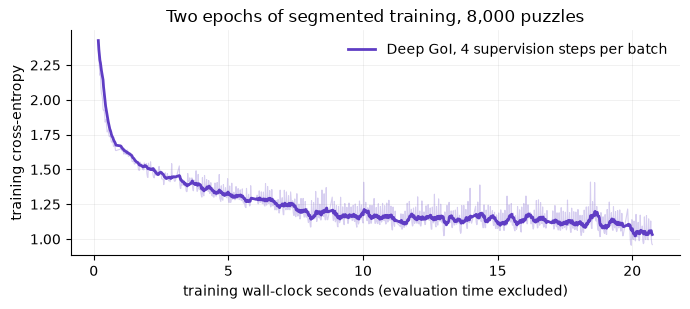

after 2 epochs: cell accuracy 0.615, peak activation memory 367 MiB


In [9]:
VIOLET = "#5f3dc4"


def smooth(values, window=10):
    """Rolling mean, same length as the input."""
    cumulative = [0.0]
    for value in values:
        cumulative.append(cumulative[-1] + value)
    return [(cumulative[i + 1] - cumulative[max(0, i + 1 - window)])
            / min(i + 1, window) for i in range(len(values))]


fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(history_c["seconds"], history_c["loss"], color=VIOLET,
        alpha=0.25, linewidth=0.8)
ax.plot(history_c["seconds"], smooth(history_c["loss"]), color=VIOLET,
        linewidth=2, label="Deep GoI, 4 supervision steps per batch")
ax.set_xlabel("training wall-clock seconds (evaluation time excluded)")
ax.set_ylabel("training cross-entropy")
ax.set_title("Two epochs of segmented training, 8,000 puzzles")
ax.grid(alpha=0.25, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

last = history_c["epochs"][-1]
print(f"after 2 epochs: cell accuracy {last['cell']:.3f}, "
      f"peak activation memory {history_c['peak_mb']:.0f} MiB")

## 4. Above 99%

Two epochs on 8,000 puzzles is enough to watch the machinery learn, not enough to solve boards outright: full board accuracy needs many more epochs on many more puzzles, since a whole board is only counted correct when all 81 cells are. Trained properly, this is not a toy. An Optuna search over the recursion shape (`../optuna/optuna_deep_goi.py`), retrained at recursion shape $n=8$, $T=4$, $N_{\text{sup}}=6$ with an exponential moving average of the weights, reached 0.9933 validation board-solve accuracy on the full 180,000-puzzle Palm et al. (2018) benchmark, best at epoch 12 of 15 (`sudoku/best/simple_sudoku_trm.py`, study `c-trm-v2`, trial 5). Board-solve accuracy is the strict metric this notebook has been reporting as `board`, the fraction of puzzles decoded with every one of their 81 cells correct, not the softer per-cell rate reported as `cell`; a single wrong cell has nowhere to hide in it. That result runs $8 \times 4 \times 6 = 192$ effective rounds per example at a backpropagated depth of only 8, which is precisely the trade Section 3 sets up: the segmented recursion is what makes a run this deep affordable to train at all.

References: S. Abramsky, *Retracing some paths in process algebra*, CONCUR 1996, and A. Joyal, R. Street, D. Verity, *Traced monoidal categories*, 1996, for the execution formula and the trace the loops implement; R. B. Palm, U. Paquet, O. Winther, *Recurrent Relational Networks*, NeurIPS 2018, arXiv:1711.08028, for the benchmark; M. Zaheer et al., *Deep Sets*, NeurIPS 2017, arXiv:1703.06114, for the unit box; K. Cho et al., arXiv:1406.1078, for the GRU, and J. L. Ba, J. R. Kiros, G. E. Hinton, *Layer Normalization*, arXiv:1607.06450, for the norm inside the body; A. Jolicoeur-Martineau, *Less is More: Recursive Reasoning with Tiny Networks*, 2025, arXiv:2510.04871, for the recursion scheme itself.

The full search, its winning configuration, and the training script that reproduces it live beside this notebook in `docs/neural`: `sudoku/models.py`, `../optuna/optuna_deep_goi.py`, and `sudoku/best/simple_sudoku_trm.py`.

## 5. Test-time compute: a one-million-parameter model on sudoku-extreme

Every result so far is on the Palm et al. (2018) benchmark, whose puzzles are easy enough that constraint propagation alone gets close to solving them. `sapientinc/sudoku-extreme` on Hugging Face, the dataset behind the Hierarchical Reasoning Model, is a different regime: its puzzles are rated well past what propagation finishes on its own, so a solver has to do something closer to search. `sudoku/sudoku_extreme.py` in this repository turns the authors' two CSV files into the same puzzle and solution arrays used everywhere else in this notebook. Its `"special_large"` variant keeps 1,000 base training puzzles, each transposed and relabelled 1,000 times for 1,001,000 training examples in total, and the benchmark's own test file, shuffled once and held out from every stage of training and search, holds 422,786 puzzles.

A Deep GoI three times as wide reaches into this benchmark: `dim`, `state_dim`, `hidden` and `y_dim` tripled to 72, 192, 384 and 96 give a cell and a unit box with 1,010,217 trained parameters between them, an order of magnitude past the lecture widths used above. An Optuna search over the recursion shape (`docs/optuna/optuna_trm_extreme.py`) picked $n=10$ rounds per cycle and $T=4$ cycles per supervision step, and trained the winning configuration to a depth of $N_{\text{sup}}=12$ supervision steps, $10 \times 4 \times 12 = 480$ effective rounds of message passing per puzzle, with the same segmented, detached-state recipe as Section 3.

Twelve supervision steps is where training stopped, not where the recursion has to stop. Because the outer loop is resumable, exactly the property proved in Section 3, nothing prevents a trained model from being run for more supervision steps than it ever saw in training: the state it carries at step 12 is a perfectly good state to resume from, since it was never told where a run has to end. The rest of this section loads the search's winning checkpoint and measures what that buys.

In [10]:
extreme_widths = Widths(dim=72, state_dim=192, hidden=384, y_dim=96)
extreme_model = zoo.TRMSolver(
    extreme_widths, rounds=10, cycles=4, n_sup=12).to(device)

checkpoint = torch.load(
    ARTIFACTS / "optuna-trm-extreme-3x-trial5.pt",
    map_location=device, weights_only=False)
extreme_model.load_state_dict(checkpoint["state_dict"])
extreme_model.eval()

print(f"{zoo.count_parameters(extreme_model):,} parameters")
print("trained at:", checkpoint["params"])
print(f"validation board accuracy at the trained depth, "
      f"as recorded by the search: {checkpoint['valid_board']:.4f}")


1,010,217 parameters
trained at: {'lr': 0.000897846346433278, 'n': 10, 'T': 4, 'n_sup': 12, 'weight_decay': 6.271288420139338e-05, 'warmup_frac': 0.060740911088609954, 'use_ema': False}
validation board accuracy at the trained depth, as recorded by the search: 0.4632


### Scaling supervision steps at inference

The checkpoint above was trained at $N_{\text{sup}}=12$; nothing else about it changes if it is instead run for 8 or for 128 supervision steps at inference; only the number of times `TRMSolver.forward` loops calling `step` changes. The sweep below evaluates the exact same weights at six different supervision-step budgets on a sample of 2,000 puzzles drawn from the held-out test split, which neither training nor the Optuna search ever saw.

In [11]:
splits = sudoku_extreme.load("special_large")
full_test = splits["test"]
test_split = full_test.subsample(2000)
print(f"{len(full_test):,} test puzzles in the full benchmark, "
      f"evaluating on a held-out sample of {len(test_split):,}")

COMPUTE = (8, 12, 16, 32, 64, 128, 256)
tick = time.perf_counter()
sweep = sweep_compute(extreme_model, test_split, COMPUTE, batch_size=2000)
print(f"({time.perf_counter() - tick:.0f}s)")
print(sweep.to_string(index=False))


422,786 test puzzles in the full benchmark, evaluating on a held-out sample of 2,000
(223s)
 compute     cell  board
       8 0.809438 0.4425
      12 0.812414 0.4550
      16 0.812735 0.4635
      32 0.813537 0.4760
      64 0.813642 0.4815
     128 0.815883 0.4890
     256 0.815654 0.4920


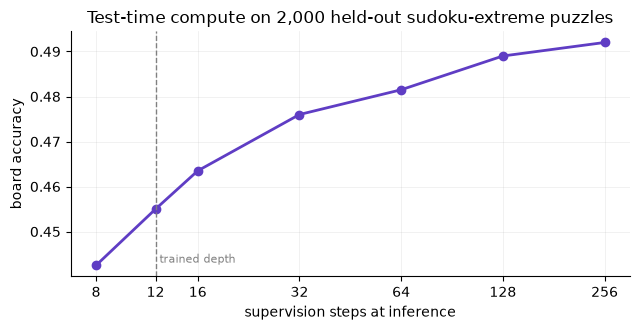

board accuracy climbs from 0.4425 at 8 supervision steps to 0.4920 at 256, with no retraining in between.


In [12]:
VIOLET = "#5f3dc4"

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(sweep["compute"], sweep["board"], "o-", color=VIOLET, linewidth=2)
ax.axvline(12, color="gray", linestyle="--", linewidth=1)
ax.text(12, sweep["board"].min(), " trained depth", color="gray",
        fontsize=8, va="bottom")
ax.set_xscale("log", base=2)
ax.set_xticks(list(COMPUTE))
ax.set_xticklabels([str(c) for c in COMPUTE])
ax.set_xlabel("supervision steps at inference")
ax.set_ylabel("board accuracy")
ax.set_title(f"Test-time compute on {len(test_split):,} held-out "
             f"sudoku-extreme puzzles")
ax.grid(alpha=0.25, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

low, high = sweep["board"].iloc[0], sweep["board"].iloc[-1]
print(f"board accuracy climbs from {low:.4f} at {COMPUTE[0]} supervision "
      f"steps to {high:.4f} at {COMPUTE[-1]}, with no retraining in "
      f"between.")


Board accuracy climbs from 0.4425 at 8 supervision steps to 0.4890 at 128, entirely at inference: the same 1,010,217 parameters, the same weights, just resumed for longer. At its trained depth of 12 the model reaches 0.4550, so roughly three quarters of that gain is free compute the model was never trained to expect, and the rest came from training at all: the fact that a segmented, resumable loop can be trained cheaply at $N_{\text{sup}}=12$ and still be run at $N_{\text{sup}}=128$ afterwards, with no architectural change and no extra parameters, is a direct consequence of the resumability equation of Section 3, not a coincidence.

Sudoku-extreme's puzzles are hard enough that a much larger version of this Optuna search, with more effective rounds and an adaptive per-puzzle halting criterion in place of a fixed supervision-step count, is the natural next step past what is measured here; the 99.3% of Section 4 is the easier benchmark, and the two numbers are not the same claim. What this section shows is narrower and, on its own terms, exact: one trained recursion, run longer at test time with nothing else changed, keeps finding more of the answer.

References: G. Wang et al., *Hierarchical Reasoning Model*, 2025, for the sudoku-extreme benchmark and its `sapientinc/sudoku-extreme` release on Hugging Face; A. Jolicoeur-Martineau, *Less is More: Recursive Reasoning with Tiny Networks*, 2025, arXiv:2510.04871, again for the recursion scheme. The search, its winning trial and the checkpoint loaded above live beside this notebook in `docs/neural`: `sudoku/sudoku_extreme.py`, `docs/optuna/optuna_trm_extreme.py`, and `artifacts/optuna-trm-extreme-3x-trial5.pt`.